In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("Water_Pipe_Leak.csv")
df

,Material,Timestep,Diameter_Inch,Roughness_mm,Pressure_PSI,Flow_LPM,Leaked_Flag,Scenario
0,PVC,1,0.75,0.0025,30.01,23.9,0,normal
1,PVC,2,0.75,0.0025,30.00,23.9,0,normal
2,PVC,3,0.75,0.0025,29.99,23.9,0,normal
3,PVC,4,0.75,0.0025,30.00,23.9,0,normal
4,PVC,5,0.75,0.0025,30.00,23.9,0,normal
...,...,...,...,...,...,...,...,...
161995,DCIP,596,12.00,0.2600,62.87,6697.7,1,intermittent
161996,DCIP,597,12.00,0.2600,62.93,6722.6,1,intermittent
161997,DCIP,598,12.00,0.2600,62.70,5654.7,1,intermittent
161998,DCIP,599,12.00,0.2600,62.44,6986.3,1,intermittent


#### Data Understanding

In [3]:
df.shape

(162000, 8)

In [4]:
df.columns

Index(['Material', 'Timestep', 'Diameter_Inch', 'Roughness_mm', 'Pressure_PSI',
       'Flow_LPM', 'Leaked_Flag', 'Scenario'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 162000 entries, 0 to 161999
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Material       162000 non-null  str    
 1   Timestep       162000 non-null  int64  
 2   Diameter_Inch  162000 non-null  float64
 3   Roughness_mm   162000 non-null  float64
 4   Pressure_PSI   162000 non-null  float64
 5   Flow_LPM       162000 non-null  float64
 6   Leaked_Flag    162000 non-null  int64  
 7   Scenario       162000 non-null  str    
dtypes: float64(4), int64(2), str(2)
memory usage: 8.7 MB


#### Check Statistic Summary

In [6]:
df.describe()

,Timestep,Diameter_Inch,Roughness_mm,Pressure_PSI,Flow_LPM,Leaked_Flag
count,162000.000000,162000.000000,162000.000000,162000.000000,162000.000000,162000.000000
mean,183.833333,4.812500,0.088000,40.353443,1556.507745,0.740741
std,128.019165,3.531307,0.121623,13.782097,2017.456430,0.438229
min,1.000000,0.750000,0.001500,15.100000,12.000000,0.000000
25%,85.000000,1.750000,0.001500,29.820000,89.850000,0.000000
50%,169.000000,4.000000,0.002500,36.470000,596.450000,1.000000
75%,254.000000,6.500000,0.260000,50.120000,2059.625000,1.000000
max,600.000000,12.000000,0.260000,74.610000,9621.300000,1.000000


#### Check data types

In [7]:
df.dtypes

Material             str
Timestep           int64
Diameter_Inch    float64
Roughness_mm     float64
Pressure_PSI     float64
Flow_LPM         float64
Leaked_Flag        int64
Scenario             str
dtype: object

#### Data Cleaning

#### Check if the are null or NaN rows

In [8]:
df.isnull().sum()

Material         0
Timestep         0
Diameter_Inch    0
Roughness_mm     0
Pressure_PSI     0
Flow_LPM         0
Leaked_Flag      0
Scenario         0
dtype: int64

#### Check duplicates

In [9]:
df.duplicated().sum()

np.int64(403)

In [10]:
df_before_duplicates = df.copy()

print("Before removing duplicates:", df.shape)
print("Rows involved in duplicates:", df.duplicated(keep=False).sum())
print("Rows that will be removed:", df.duplicated().sum())

Before removing duplicates: (162000, 8)
Rows involved in duplicates: 756
Rows that will be removed: 403


In [11]:
df = df.drop_duplicates().reset_index(drop=True)

print("After removing duplicates:", df.shape)
print("Remaining exact duplicates:", df.duplicated().sum())

After removing duplicates: (161597, 8)
Remaining exact duplicates: 0


In [12]:
df.drop(['Scenario','Timestep'], axis=1, inplace=True)

In [13]:
df.columns

Index(['Material', 'Diameter_Inch', 'Roughness_mm', 'Pressure_PSI', 'Flow_LPM',
       'Leaked_Flag'],
      dtype='str')

In [14]:
print(df["Leaked_Flag"].value_counts())

Leaked_Flag
1    119684
0     41913
Name: count, dtype: int64


In [15]:
numerical_columns = [
    "Diameter_Inch",
    "Roughness_mm",
    "Pressure_PSI",
    "Flow_LPM"
]

for column in numerical_columns:
    
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ]
    
    print("Column:", column)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower limit:", lower_limit)
    print("Upper limit:", upper_limit)
    print("Number of outliers:", len(outliers))
    print("-" * 50)

Column: Diameter_Inch
Q1: 2.0
Q3: 8.0
IQR: 6.0
Lower limit: -7.0
Upper limit: 17.0
Number of outliers: 0
--------------------------------------------------
Column: Roughness_mm
Q1: 0.0015
Q3: 0.26
IQR: 0.2585
Lower limit: -0.38625000000000004
Upper limit: 0.64775
Number of outliers: 0
--------------------------------------------------
Column: Pressure_PSI
Q1: 29.84
Q3: 50.18
IQR: 20.34
Lower limit: -0.6699999999999982
Upper limit: 80.69
Number of outliers: 0
--------------------------------------------------
Column: Flow_LPM
Q1: 127.9
Q3: 2129.6
IQR: 2001.6999999999998
Lower limit: -2874.6499999999996
Upper limit: 5132.15
Number of outliers: 13866
--------------------------------------------------


In [16]:
for diameter in sorted(df["Diameter_Inch"].unique()):
    
    data = df[df["Diameter_Inch"] == diameter]["Flow_LPM"]
    
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = data[
        (data < lower) | (data > upper)
    ]
    
    print(f"Diameter: {diameter} inch")
    print(f"Lower: {lower:.2f}")
    print(f"Upper: {upper:.2f}")
    print(f"Outliers: {len(outliers)}")
    print("-" * 40)

Diameter: 0.75 inch
Lower: 17.50
Upper: 27.90
Outliers: 364
----------------------------------------
Diameter: 1.0 inch
Lower: 22.75
Upper: 53.55
Outliers: 59
----------------------------------------
Diameter: 2.0 inch
Lower: 127.95
Upper: 197.95
Outliers: 530
----------------------------------------
Diameter: 3.0 inch
Lower: 254.90
Upper: 381.30
Outliers: 783
----------------------------------------
Diameter: 4.0 inch
Lower: 395.20
Upper: 851.20
Outliers: 100
----------------------------------------
Diameter: 6.0 inch
Lower: 782.85
Upper: 2185.65
Outliers: 20
----------------------------------------
Diameter: 8.0 inch
Lower: 2209.90
Upper: 3584.30
Outliers: 383
----------------------------------------
Diameter: 10.0 inch
Lower: 3349.02
Upper: 5794.03
Outliers: 224
----------------------------------------
Diameter: 12.0 inch
Lower: 4838.55
Upper: 8362.55
Outliers: 262
----------------------------------------


In [17]:
flow_outliers = pd.DataFrame()

for diameter in sorted(df["Diameter_Inch"].unique()):

    data = df[df["Diameter_Inch"] == diameter]

    Q1 = data["Flow_LPM"].quantile(0.25)
    Q3 = data["Flow_LPM"].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[
        (data["Flow_LPM"] < lower) |
        (data["Flow_LPM"] > upper)
    ]

    flow_outliers = pd.concat([flow_outliers, outliers])

print(flow_outliers["Leaked_Flag"].value_counts())

Leaked_Flag
1    2567
0     158
Name: count, dtype: int64


#### EDA (Exploratory Data Analysis)

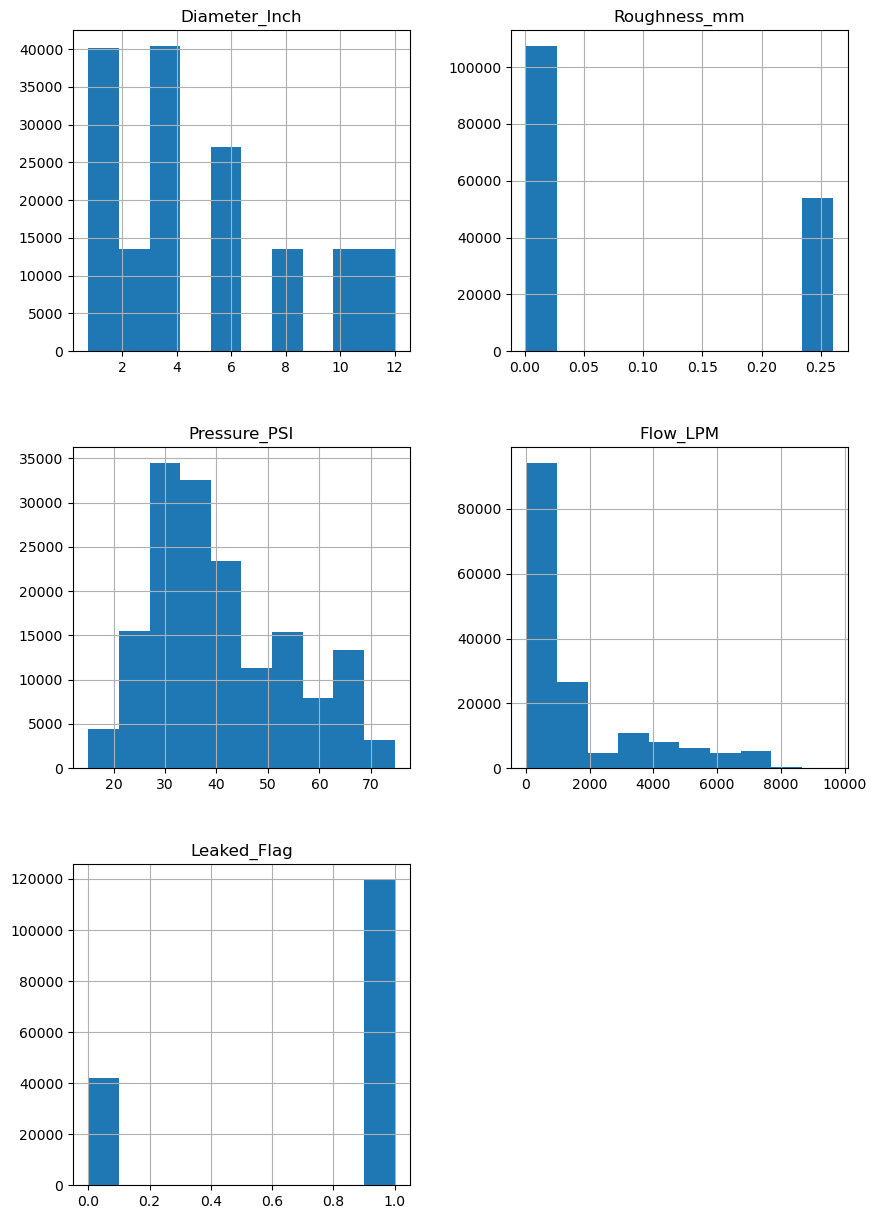

In [18]:
df.hist(figsize=(10,15))
plt.show()

#### bar graph: Material

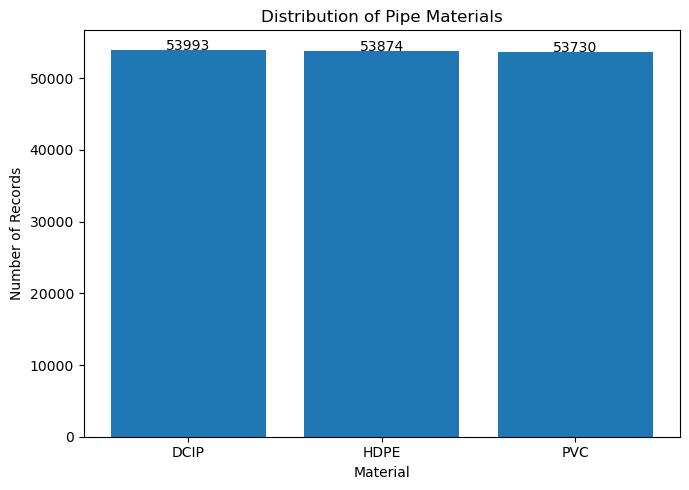

In [19]:

material_counts = df["Material"].value_counts()

plt.figure(figsize=(7, 5))

bars = plt.bar(material_counts.index, material_counts.values)

plt.title("Distribution of Pipe Materials")
plt.xlabel("Material")
plt.ylabel("Number of Records")

for bar, value in zip(bars, material_counts.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        str(value),
        ha="center"
    )

plt.tight_layout()
plt.show()

#### bar graph: Leak Status

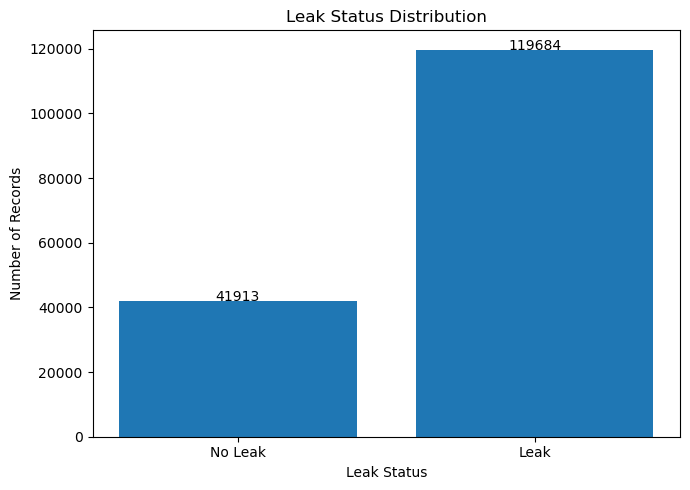

In [20]:
leak_counts = df["Leaked_Flag"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

bars = plt.bar(
    ["No Leak", "Leak"],
    leak_counts.values
)

plt.title("Leak Status Distribution")
plt.xlabel("Leak Status")
plt.ylabel("Number of Records")

for bar, value in zip(bars, leak_counts.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        str(value),
        ha="center"
    )

plt.tight_layout()
plt.show()

#### Pressure vs Flow

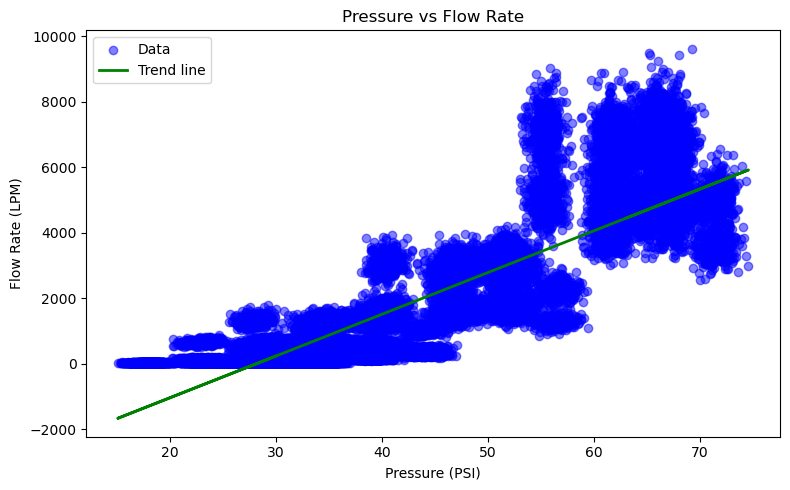

In [21]:
import numpy as np

plt.figure(figsize=(8, 5))

# Scatter plot
plt.scatter(
    df["Pressure_PSI"],
    df["Flow_LPM"],
    color="blue",
    alpha=0.5,
    label="Data"
)

# Trend line
z = np.polyfit(df["Pressure_PSI"], df["Flow_LPM"], 1)
p = np.poly1d(z)

plt.plot(
    df["Pressure_PSI"],
    p(df["Pressure_PSI"]),
    color="green",
    linewidth=2,
    label="Trend line"
)

plt.title("Pressure vs Flow Rate")
plt.xlabel("Pressure (PSI)")
plt.ylabel("Flow Rate (LPM)")
plt.legend()

plt.tight_layout()
plt.show()

#### Average Pressure by Leak Status

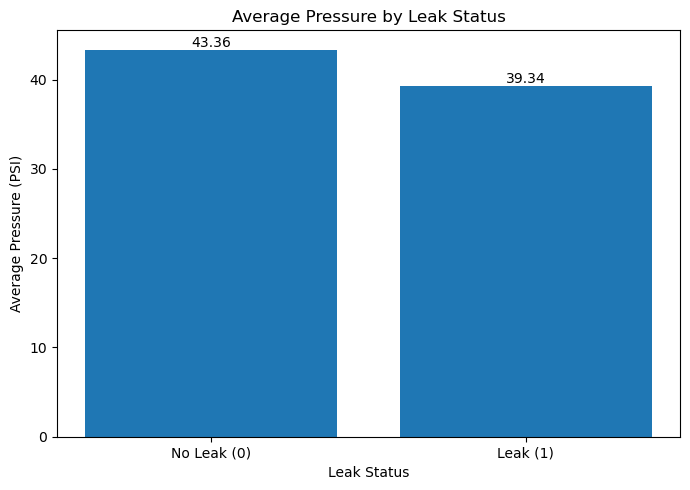

In [22]:

# Calculate average pressure for each leak status
pressure_by_leak = df.groupby("Leaked_Flag")["Pressure_PSI"].mean()

plt.figure(figsize=(7, 5))

bars = plt.bar(
    ["No Leak (0)", "Leak (1)"],
    pressure_by_leak.values
)

plt.title("Average Pressure by Leak Status")
plt.xlabel("Leak Status")
plt.ylabel("Average Pressure (PSI)")

# Add values above bars
for bar, value in zip(bars, pressure_by_leak.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

#### Correlation

In [23]:
numeric_columns = [
    "Diameter_Inch",
    "Roughness_mm",
    "Pressure_PSI",
    "Flow_LPM",
    "Leaked_Flag"
]

correlation = df[numeric_columns].corr()

print(correlation)

               Diameter_Inch  Roughness_mm  Pressure_PSI  Flow_LPM  \
Diameter_Inch       1.000000      0.837775      0.907441  0.944671   
Roughness_mm        0.837775      1.000000      0.854578  0.819450   
Pressure_PSI        0.907441      0.854578      1.000000  0.870143   
Flow_LPM            0.944671      0.819450      0.870143  1.000000   
Leaked_Flag         0.000230      0.000151     -0.127782 -0.004560   

               Leaked_Flag  
Diameter_Inch     0.000230  
Roughness_mm      0.000151  
Pressure_PSI     -0.127782  
Flow_LPM         -0.004560  
Leaked_Flag       1.000000  


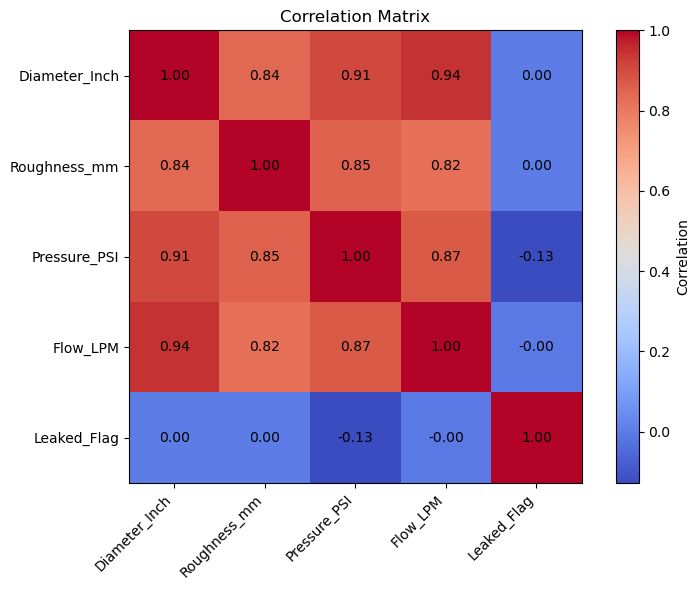

In [24]:
plt.figure(figsize=(8, 6))

plt.imshow(correlation, cmap="coolwarm", interpolation="nearest")

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")

# Display correlation values
for i in range(len(correlation)):
    for j in range(len(correlation)):
        plt.text(
            j,
            i,
            f"{correlation.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

#### Prepare the data

In [25]:
# Features and target

X = df[
    [
        "Material",
        "Diameter_Inch",
        "Roughness_mm",
        "Pressure_PSI",
        "Flow_LPM"
    ]
]

y = df["Leaked_Flag"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (161597, 5)
y shape: (161597,)


#### Encode Material

In [26]:
X = pd.get_dummies(
    X,
    columns=["Material"],
    drop_first=True
)

print(X.head())
print(X.dtypes)

   Diameter_Inch  Roughness_mm  Pressure_PSI  Flow_LPM  Material_HDPE  \
0           0.75        0.0025         30.01      23.9          False   
1           0.75        0.0025         30.00      23.9          False   
2           0.75        0.0025         29.99      23.9          False   
3           0.75        0.0025         30.00      23.9          False   
4           0.75        0.0025         30.00      23.9          False   

   Material_PVC  
0          True  
1          True  
2          True  
3          True  
4          True  
Diameter_Inch    float64
Roughness_mm     float64
Pressure_PSI     float64
Flow_LPM         float64
Material_HDPE       bool
Material_PVC        bool
dtype: object


####  Train/Test Split

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

Training data: (129277, 6)
Testing data: (32320, 6)

Training target:
Leaked_Flag
1    95747
0    33530
Name: count, dtype: int64

Testing target:
Leaked_Flag
1    23937
0     8383
Name: count, dtype: int64


#### Balance ONLY the training data

In [28]:
print(y_train.value_counts())

Leaked_Flag
1    95747
0    33530
Name: count, dtype: int64


#### Balance the training data manually

In [29]:
# Combine X_train and y_train
train_data = X_train.copy()
train_data["Leaked_Flag"] = y_train.values

# Separate the two classes
no_leak = train_data[train_data["Leaked_Flag"] == 0]
leak = train_data[train_data["Leaked_Flag"] == 1]

# Find the larger class
max_count = max(len(no_leak), len(leak))

# Oversample the smaller class
no_leak_oversampled = no_leak.sample(
    n=max_count,
    replace=True,
    random_state=42
)

leak_oversampled = leak.sample(
    n=max_count,
    replace=True,
    random_state=42
)

# Combine the classes
train_balanced = pd.concat(
    [no_leak_oversampled, leak_oversampled]
)

# Shuffle the data
train_balanced = train_balanced.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

# Separate X and y
X_train_balanced = train_balanced.drop(
    "Leaked_Flag",
    axis=1
)

y_train_balanced = train_balanced["Leaked_Flag"]

# Check the results
print("Before balancing:")
print(y_train.value_counts())

print("\nAfter oversampling:")
print(y_train_balanced.value_counts())

Before balancing:
Leaked_Flag
1    95747
0    33530
Name: count, dtype: int64

After oversampling:
Leaked_Flag
1    95747
0    95747
Name: count, dtype: int64


In [30]:
print("Test set:")
print(y_test.value_counts())

Test set:
Leaked_Flag
1    23937
0     8383
Name: count, dtype: int64


#### Train the ML models

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC

#### Create the models

In [32]:

models_tuned = {

    "Logistic Regression": LogisticRegression(
        max_iter=500
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=7,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        max_depth=2,
        min_samples_split=20,
        min_samples_leaf=10,
        learning_rate=0.05,
        random_state=42
    )
}

#### Train and test all models

In [33]:
from sklearn.metrics import accuracy_score

results = []

for name, model in models_tuned.items():

    print(f"\nTraining {name}...")

    # Train on balanced training data
    model.fit(
        X_train_balanced,
        y_train_balanced
    )

    print(f"Testing {name}...")

    # Training accuracy
    train_pred = model.predict(X_train_balanced)
    train_accuracy = accuracy_score(
        y_train_balanced,
        train_pred
    )

    # Testing accuracy
    test_pred = model.predict(X_test)
    test_accuracy = accuracy_score(
        y_test,
        test_pred
    )

    difference = train_accuracy - test_accuracy

    results.append({
        "Model": name,
        "Training Accuracy": train_accuracy * 100,
        "Testing Accuracy": test_accuracy * 100,
        "Difference": difference * 100
    })

    print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
    print(f"Testing Accuracy: {test_accuracy * 100:.2f}%")
    print(f"Difference: {difference * 100:.2f}%")


Training Logistic Regression...
Testing Logistic Regression...
Training Accuracy: 69.80%
Testing Accuracy: 67.94%
Difference: 1.86%

Training Decision Tree...
Testing Decision Tree...
Training Accuracy: 94.95%
Testing Accuracy: 94.33%
Difference: 0.63%

Training Random Forest...
Testing Random Forest...
Training Accuracy: 93.51%
Testing Accuracy: 92.42%
Difference: 1.10%

Training Gradient Boosting...
Testing Gradient Boosting...
Training Accuracy: 92.57%
Testing Accuracy: 91.48%
Difference: 1.09%


In [34]:
results_df = pd.DataFrame(results)

print("\n===== TUNED MODEL RESULTS =====")
print(results_df.round(2))


===== TUNED MODEL RESULTS =====
                 Model  Training Accuracy  Testing Accuracy  Difference
0  Logistic Regression              69.80             67.94        1.86
1        Decision Tree              94.95             94.33        0.63
2        Random Forest              93.51             92.42        1.10
3    Gradient Boosting              92.57             91.48        1.09


#### confusion_matrix

Confusion Matrix:
[[ 8006   377]
 [ 2074 21863]]


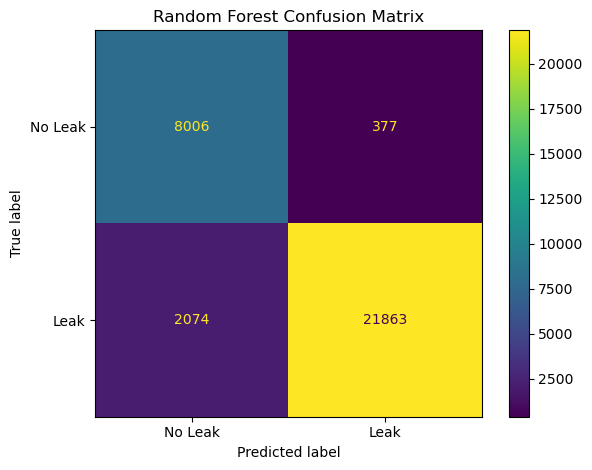

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get the Random Forest
random_forest = models_tuned["Random Forest"]

# Predict on the original test data
y_pred_rf = random_forest.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix:")
print(cm)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Leak", "Leak"]
)

disp.plot()

plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

In [36]:
from sklearn.metrics import classification_report

print("Random Forest Classification Report")
print("=" * 50)

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["No Leak", "Leak"]
    )
)

Random Forest Classification Report
              precision    recall  f1-score   support

     No Leak       0.79      0.96      0.87      8383
        Leak       0.98      0.91      0.95     23937

    accuracy                           0.92     32320
   macro avg       0.89      0.93      0.91     32320
weighted avg       0.93      0.92      0.93     32320



#### Calculate feature importance

In [37]:
# Get feature importance
importance = random_forest.feature_importances_

# Create DataFrame
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
})

# Sort from highest to lowest
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

         Feature  Importance
2   Pressure_PSI    0.738898
3       Flow_LPM    0.192822
0  Diameter_Inch    0.045482
1   Roughness_mm    0.009498
5   Material_PVC    0.009419
4  Material_HDPE    0.003881


#### Predict  future observations

In [38]:
# ==========================================
# NEW PIPE DATA
# ==========================================

new_pipe = pd.DataFrame([[
    3.0,      # Diameter_Inch
    0.16,     # Roughness_mm
    49.0,     # Pressure_PSI
    600.0,    # Flow_LPM
    True,     # Material_HDPE if T and F it HDPE if F and T PVC
    False     # Material_PVC if F and F is DCIP
]], columns=X_train.columns)


# ==========================================
# PREDICTION
# ==========================================

prediction = random_forest.predict(new_pipe)

if prediction[0] == 1:
    print("Prediction: LEAK")
else:
    print("Prediction: NO LEAK")


# ==========================================
# GET PROBABILITIES
# ==========================================

probability = random_forest.predict_proba(new_pipe)[0]

print("Probability of NO LEAK:", round(probability[0] * 100, 2), "%")
print("Probability of LEAK:", round(probability[1] * 100, 2), "%")

Prediction: LEAK
Probability of NO LEAK: 47.15 %
Probability of LEAK: 52.85 %


#### ROC_AUC (ROC = Receiver Operating Characteristic, AUC = Area Under the Curve)

In [39]:
from sklearn.metrics import roc_auc_score

# Get the trained Random Forest model
random_forest = models_tuned["Random Forest"]

# Get probability of class 1 (LEAK)
y_prob = random_forest.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)

print("Random Forest ROC-AUC:", roc_auc)

Random Forest ROC-AUC: 0.9745059836905072


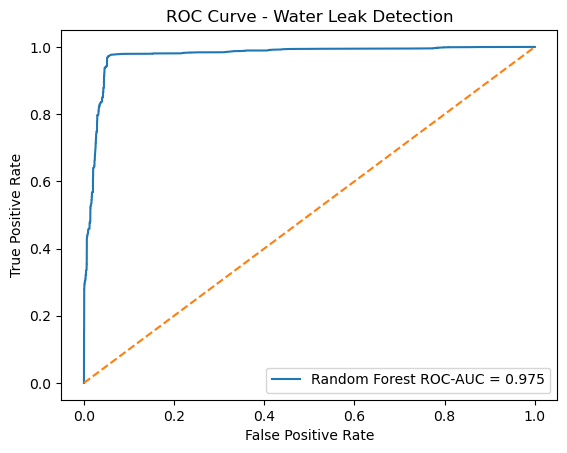

In [40]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get the trained Random Forest model
random_forest = models_tuned["Random Forest"]

# Get probability of class 1 (LEAK)
y_prob = random_forest.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate ROC-AUC
auc = roc_auc_score(y_test, y_prob)

# Plot ROC curve
plt.plot(fpr, tpr, label=f"Random Forest ROC-AUC = {auc:.3f}")

# Random guessing line
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Water Leak Detection")
plt.legend()
plt.show()

#### Save the Decision Tree model and  feature names

In [41]:
import joblib

# Get the trained Random Forest
random_forest = models_tuned["Random Forest"]

# Store model and feature names
model_data = {
    "model": random_forest,
    "features": X_train.columns.tolist()
}

# Save the Random Forest
joblib.dump(model_data, "random_forest_leak_model.pkl")

print("Random Forest model and feature names saved successfully.")

Random Forest model and feature names saved successfully.


#### Load the model

In [42]:
import joblib

# ==========================================
# LOAD THE SAVED RANDOM FOREST MODEL
# ==========================================

model_data = joblib.load("random_forest_leak_model.pkl")

# Get the model
loaded_model = model_data["model"]

# Get feature names
feature_names = model_data["features"]

print("Random Forest model loaded successfully.")

print("Features:")
print(feature_names)

Random Forest model loaded successfully.
Features:
['Diameter_Inch', 'Roughness_mm', 'Pressure_PSI', 'Flow_LPM', 'Material_HDPE', 'Material_PVC']


In [44]:
result = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_rf
})

result['Actual'] = result['Actual'].map({
    0: 'Not Leak',
    1: 'Leak'
})

result['Predicted'] = result['Predicted'].map({
    0: 'Not Leak',
    1: 'Leak'
})

print(result.head(30))

          Actual Predicted
50666       Leak  Not Leak
79622   Not Leak  Not Leak
85567       Leak      Leak
139643      Leak      Leak
159017      Leak      Leak
135952  Not Leak  Not Leak
151743      Leak      Leak
69676       Leak      Leak
24463   Not Leak  Not Leak
144118      Leak      Leak
60480       Leak      Leak
67744   Not Leak  Not Leak
136262      Leak      Leak
30999       Leak      Leak
85656       Leak      Leak
93932       Leak      Leak
130483      Leak  Not Leak
77511       Leak  Not Leak
38284       Leak      Leak
90756       Leak  Not Leak
121089      Leak      Leak
83133       Leak      Leak
95293   Not Leak      Leak
161413      Leak      Leak
45367       Leak      Leak
49156       Leak  Not Leak
31814       Leak      Leak
146390  Not Leak  Not Leak
40896   Not Leak  Not Leak
92461   Not Leak  Not Leak


#### Check the loaded ds if it works

In [45]:
# ==========================================
# PREDICTION
# ==========================================

prediction = loaded_model.predict(new_pipe)

probability = loaded_model.predict_proba(new_pipe)[0]


# ==========================================
# RESULT
# ==========================================

if prediction[0] == 1:
    print("Prediction: LEAK")
else:
    print("Prediction: NO LEAK")


# ==========================================
# PROBABILITIES
# ==========================================

print("Probability of NO LEAK:", round(probability[0] * 100, 2), "%")
print("Probability of LEAK:", round(probability[1] * 100, 2), "%")

Prediction: LEAK
Probability of NO LEAK: 47.15 %
Probability of LEAK: 52.85 %
